# Beyond tiles: free-form still-life images

This notebook walks through the algorithm developed in the *beyond-tiles*
feasibility spike (`experiments/beyond_tiles/`, full analysis in its
`REPORT.md`): mapping a greyscale image onto **one large Game-of-Life still
life** whose local live-cell density follows the image — with **no tile
vocabulary at all**.

The classic pipeline in this repository (Bosch & Olivieri style) fills the
canvas with pre-enumerated still-life *tiles*. Here instead a constraint
solver (Google OR-Tools **CP-SAT**) places every cell individually, subject
to:

1. **Stability (hard):** the whole pattern is a still life — every live cell
   has 2 or 3 live neighbours, no dead cell has exactly 3.
2. **Density (soft):** the canvas is divided into 8×8 windows; each window
   should contain a target number of live cells derived from the image's
   local grey value. The solver minimises the total deviation.

Closest prior art: Verrill, *Conway Still Life Drawing* (Bridges 2022) —
non-modular but binary masks only, fixed ~50% density, hours of annealing
for 40×40. The CP-SAT approach solves density-graded 200×200 portraits to
proven optimality in ~90 s.


## 0. Setup

Requires the `beyond` extra (`pip install ortools`).

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (REPO / "src", REPO / "experiments"):
    sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

## 1. From image to greyscale + subject mask

We reuse the tile pipeline's loader (`gol_mosaics.image_processing`): alpha
handling, optional background removal, sigmoid contrast — then pad to a
square and Lanczos-resize straight to the *cell grid*. One pixel = one
Game-of-Life cell. The alpha channel becomes the subject mask; background
cells will be forced dead.

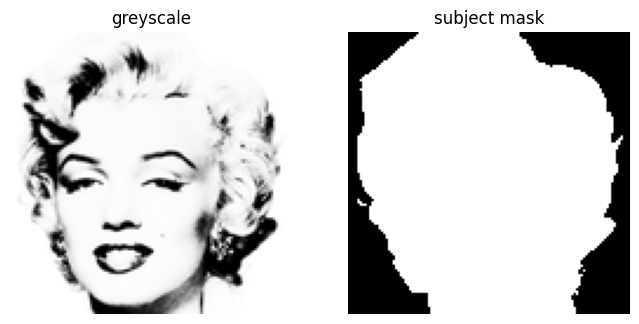

In [2]:
from beyond_tiles.targets import grey_and_mask_from_image

SIZE = 120  # cells per side — small enough to solve in ~a minute
grey, free = grey_and_mask_from_image(REPO / "input/images/marilyn.png", SIZE)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(grey, cmap="gray"); axes[0].set_title("greyscale")
axes[1].imshow(free, cmap="gray"); axes[1].set_title("subject mask")
for ax in axes: ax.axis("off")

## 2. Tone mapping — the step that actually decides the picture

The spike's key debugging lesson: the solver was never the problem, the
*targets* were. This photo is high-key (subject median grey ≈ 234), so a
faithful absolute mapping `density = d_max · (1 − grey/255)` leaves the face
at density ≈ 0.03 — an unrecognisable scatter, even when the solver matches
it perfectly.

The fix mirrors what the tile pipeline does implicitly with its *relative*
density mapping: **histogram-equalize the grey values inside the subject
mask**. The subject's tones then span the full range and its median lands
near density 0.2 — the sweet spot for organic still-life texture.

Text(0.5, 1.0, 'subject histogram, equalized')

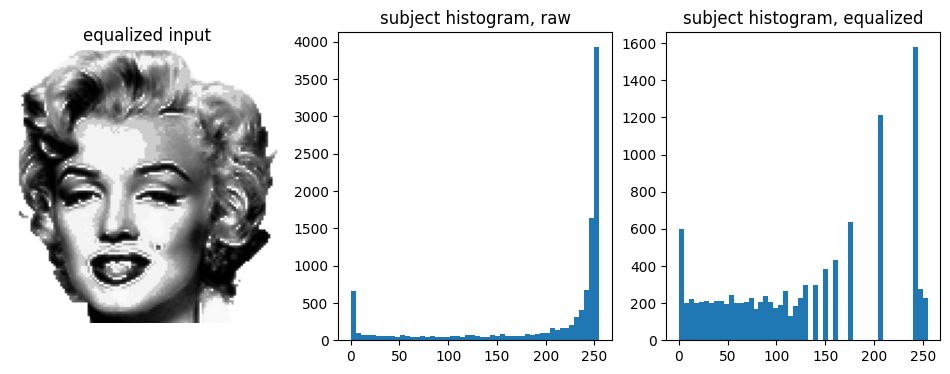

In [3]:
from beyond_tiles.targets import equalize_grey

eq = equalize_grey(grey, free)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(eq, cmap="gray"); axes[0].set_title("equalized input"); axes[0].axis("off")
axes[1].hist(grey[free], bins=50); axes[1].set_title("subject histogram, raw")
axes[2].hist(eq[free], bins=50); axes[2].set_title("subject histogram, equalized")

## 3. Density targets per window

Per cell: `d = d_max · (1 − g/255)`, with `d_max = 0.45`. Elkies (1998)
proved still lifes cannot exceed density ½ asymptotically, so greyscale must
live in `[0, ~0.5]`; 0.45 leaves slack.

The canvas is covered by **disjoint 8×8 windows** and each window gets an
integer live-cell target (summed over its unmasked cells). The spike tested
50%-overlapping windows first — they only make the optimization 20–50×
harder; disjoint windows solve to *zero* total deviation with no visible
seams, because the stability constraints already couple neighbouring
windows.

192 windows, live-cell targets from 0 to 28


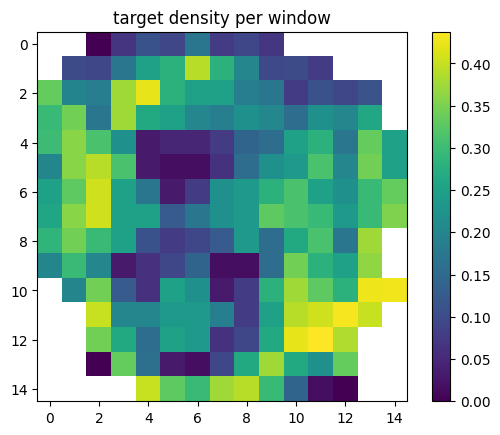

In [4]:
from beyond_tiles.targets import cell_targets, window_slices, window_targets

D_MAX, K = 0.45, 8
cell_t = cell_targets(eq, d_max=D_MAX)
windows = window_slices(cell_t.shape, k=K, stride=K)
targets, kept = window_targets(cell_t, free, windows)
print(f"{len(kept)} windows, live-cell targets from {targets.min()} to {targets.max()}")

field = np.full((SIZE // K + (SIZE % K > 0),) * 2, np.nan)
for t, (si, sj) in zip(targets, kept):
    field[si.start // K, sj.start // K] = t / free[si, sj].sum()
plt.imshow(field, cmap="viridis"); plt.title("target density per window"); plt.colorbar();

## 4. The constraint model

One boolean per cell on an (H+2)×(W+2) grid. The border ring is forced dead
**but still carries the no-birth constraint** — without it, a ring cell with
exactly 3 live interior neighbours would come alive in generation 1 and the
"still life" would ripple when opened in Golly.

For every cell, with `S` = sum of its in-grid Moore neighbours:

- **alive ⇒ S ∈ [2, 3]**  (survival)
- **dead ⇒ S ∈ {0,1,2} ∪ {4,…,8}**  (no birth)

both as half-reified linear constraints — CP-SAT handles these natively, no
auxiliary variables. Each kept window `w` gets `dev_w ≥ |Σ cells − t_w|` via
two inequalities, and the objective is `min Σ dev_w`. An all-dead grid is
trivially feasible, so the solver always holds an incumbent and improves it
("anytime" behaviour); with disjoint windows it typically reaches proven
optimality.

In [5]:
from beyond_tiles.still_image import SpikeConfig, solve_image

cfg = SpikeConfig(k=K, stride=K, d_max=D_MAX, time_limit_s=120.0, workers=10, seed=0)
result = solve_image(eq, free, cfg)
print(result.status, "| objective:", result.objective,
      f"| {result.wall_time_s:.1f}s | live cells: {int(result.pattern.sum())}")

OPTIMAL | objective: 1 | 21.6s | live cells: 2406


## 5. Verify: is it really a still life?

Two independent checks (plus, for the spike's headline patterns, a third via
`cellpylib` and a manual Golly session):

- `gol_mosaics.life.is_still_life` on the pattern padded by one dead ring —
  this check is *complete*: a birth two cells away from the pattern is
  impossible, so pad-1 covers every cell that could ever change.
- `gol_mosaics.sat_search.rule_violations` — an independent, vectorised
  toroidal implementation from the tile-census code path.

In [6]:
from beyond_tiles.still_image import verify_still_life

verify_still_life(result.pattern)

{'bounded': True, 'toroidal': True}

## 6. Look at it — and at how well density was matched


{'mad': 0.0087, 'p95': 0.0212, 'max': 0.3724, 'mad_darkest_quartile': 0.0165, 'pearson': 0.9592, 'n_windows': 192}


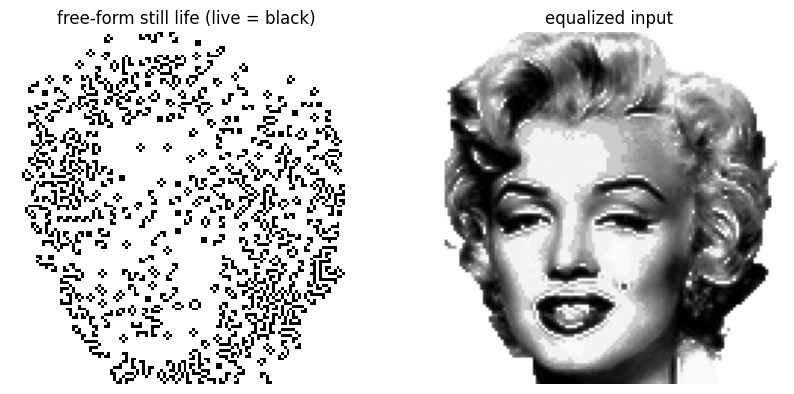

In [7]:
from beyond_tiles.metrics import deviation_stats

stats = deviation_stats(result.pattern, cell_t, free, kept)
print({k: round(v, 4) if isinstance(v, float) else v for k, v in stats.items()})

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(1 - result.pattern, cmap="gray", interpolation="nearest")
axes[0].set_title("free-form still life (live = black)")
axes[1].imshow(eq, cmap="gray"); axes[1].set_title("equalized input")
for ax in axes: ax.axis("off")

## 7. Export for Golly

`.cells` format via the repo's exporter. Open in Golly and press step —
nothing may move.

In [8]:
from gol_mosaics.export import GollyExporter

out = REPO / "output/golly/beyond_tiles_demo.cells"
out.parent.mkdir(parents=True, exist_ok=True)
GollyExporter.export_to_cells(result.pattern, str(out))
print("written:", out)

written: /Users/michielrollier/Developer/GitHub/game-of-life-mosaics/output/golly/beyond_tiles_demo.cells


## 8. Scaling up: the 200² and 400² solutions

The 120² demo above solves in about half a minute; the pictures that
actually make the case are bigger. Two of them ship with the repository as
compact assets (`experiments/beyond_tiles/assets/`, bit-packed patterns of
3.6 kB and 12 kB plus their solver logs), because the full run directories
are gitignored:

- **200² — proven optimal.** CP-SAT closed the gap: no still life matches
  the requested densities better than this one.
- **400² — best incumbent after a 40-minute cap.** Still verified static,
  and visually the best of the series, but *not* proven optimal.

Both were produced with the recommended settings (disjoint 8×8 windows,
`d_max = 0.45`, equalized tone, background forced dead) on an Apple M4 with
10 solver workers.

In [9]:
import json
from beyond_tiles.artifacts import ASSETS, load_pattern_asset
from beyond_tiles.still_image import verify_still_life

hires = {}
for size, tag in ((200, "optimal"), (400, "feasible")):
    pattern = load_pattern_asset(ASSETS / f"marilyn_{size}_{tag}.npz")
    met = json.loads((ASSETS / f"metrics_{size}.json").read_text())
    hires[size] = (pattern, met)
    dev = met["deviation"]
    print(
        f"{size}²: {met['status']:8s} objective {met['objective']:5d} "
        f"(bound {met['best_bound']:>4}) | {met['wall_time_s']:7.1f} s | "
        f"MAD {dev['mad']:.4f} | darkest quartile {dev['mad_darkest_quartile']:.4f} | "
        f"peak RAM {met['max_rss_mb'] / 1024:.1f} GB | {int(pattern.sum()):6d} live cells"
    )
    print(f"       re-verified from the shipped asset: {verify_still_life(pattern)}")

200²: OPTIMAL  objective     2 (bound    2) |    86.9 s | MAD 0.0091 | darkest quartile 0.0076 | peak RAM 2.6 GB |   6719 live cells
       re-verified from the shipped asset: {'bounded': True, 'toroidal': True}
400²: FEASIBLE objective  2874 (bound    2) |  2403.9 s | MAD 0.0288 | darkest quartile 0.0816 | peak RAM 4.5 GB |  24295 live cells
       re-verified from the shipped asset: {'bounded': True, 'toroidal': True}


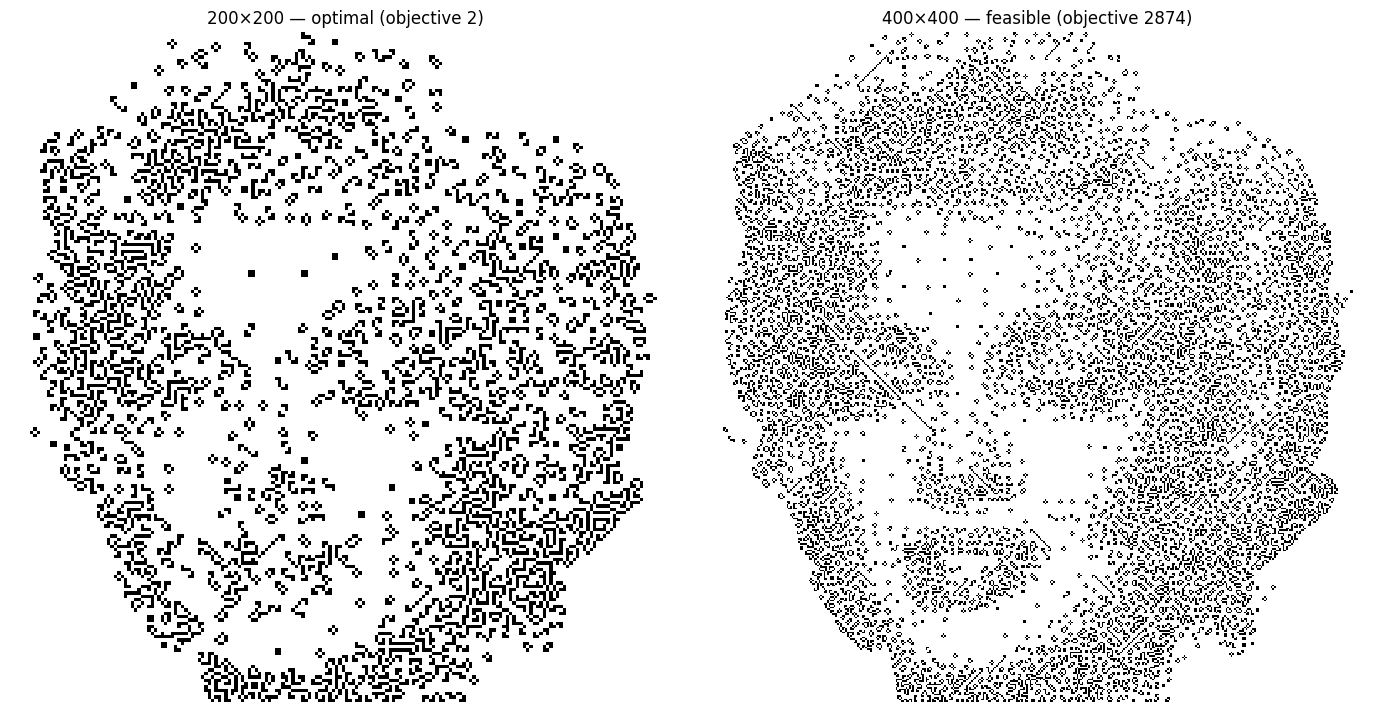

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, size in zip(axes, (200, 400)):
    pattern, met = hires[size]
    ax.imshow(1 - pattern, cmap="gray", interpolation="nearest")
    ax.set_title(f"{size}×{size} — {met['status'].lower()} (objective {met['objective']})")
    ax.axis("off")
fig.tight_layout()

### What resolution buys: the same patch of face at three scales

Below is one image region — mouth and chin — cropped from the 120², 200² and
400² solutions and blown up to the same display size. The number of *cells*
per crop quadruples each time, and with it what the pattern can express:

- at 120² the region is a handful of individual still-life motifs, and the
  eye reads the ornament rather than the face;
- at 400² a motif is small compared with the lip edge, so the same texture
  reads as **tone**. Nothing about the vocabulary changed — only how much of
  it fits inside an image feature.

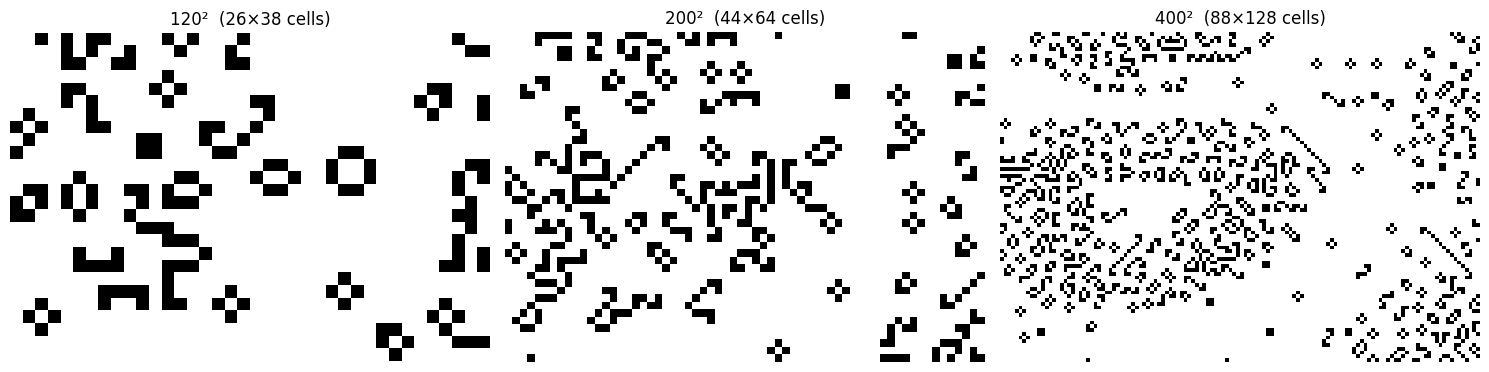

In [11]:
BOX = (0.68, 0.90, 0.30, 0.62)  # (row0, row1, col0, col1) as fractions of the canvas

crops = [(120, result.pattern), (200, hires[200][0]), (400, hires[400][0])]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (size, pattern) in zip(axes, crops):
    r0, r1, c0, c1 = (int(round(f * size)) for f in BOX)
    ax.imshow(1 - pattern[r0:r1, c0:c1], cmap="gray", interpolation="nearest")
    ax.set_title(f"{size}²  ({r1 - r0}×{c1 - c0} cells)")
    ax.axis("off")
fig.tight_layout()

### What resolution costs: the optimality wall

| Size | Windows | Booleans | Status | Objective (bound) | Wall time | MAD | Darkest-quartile MAD | Pearson | Peak RAM |
|------|---------|----------|--------|-------------------|-----------|-----|----------------------|---------|----------|
| 100² | 144   | 10.4 k | OPTIMAL | 0 (0)      | 16 s     | 0.0086 | —      | —     | 1.2 GB |
| 200² | 509   | 40.8 k | OPTIMAL | 2 (2)      | 87 s     | 0.0091 | 0.0076 | 0.951 | 2.7 GB |
| 400² | 1,968 | 161 k  | FEASIBLE (capped) | 2,874 (2) | 2,404 s | 0.0288 | 0.0816 | 0.923 | 4.6 GB |

The model itself grows only *linearly* in the number of cells — it is
proving optimality that explodes. The convergence logs show the shape of
that wall: at 200² the objective collapses to its optimum inside two
minutes, while at 400² it is still falling steadily when the cap stops it,
with the lower bound stuck near zero the whole time.

(For contrast, the same 200² image with 50 %-**overlapping** windows was
still at objective 662 after 901 s — overlap is what makes the problem hard,
not resolution alone.)

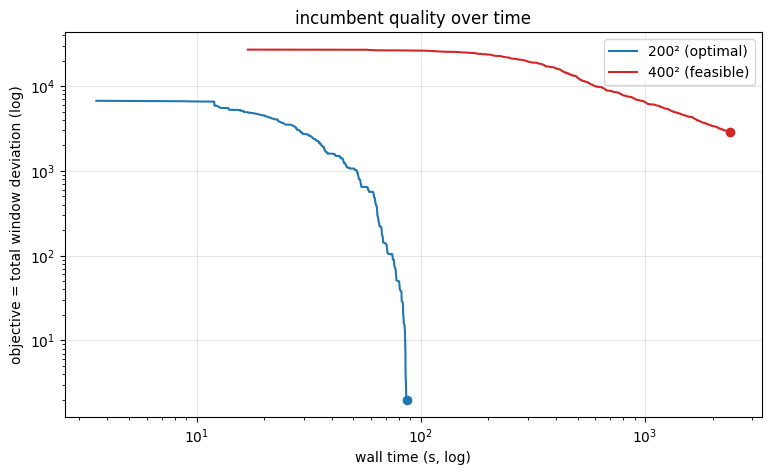

In [12]:
import csv
import gzip

fig, ax = plt.subplots(figsize=(9, 5))
for size, colour in ((200, "tab:blue"), (400, "tab:red")):
    with gzip.open(ASSETS / f"convergence_{size}.csv.gz", "rt") as fh:
        rows = np.array([[float(t), float(o)] for t, o in list(csv.reader(fh))[1:]])
    met = hires[size][1]
    ax.plot(rows[:, 0], rows[:, 1], color=colour, label=f"{size}² ({met['status'].lower()})")
    ax.scatter([met["wall_time_s"]], [max(met["objective"], 1)], color=colour, zorder=3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("wall time (s, log)")
ax.set_ylabel("objective = total window deviation (log)")
ax.set_title("incumbent quality over time")
ax.legend()
ax.grid(alpha=0.3)

### Watching the solver converge — when is a cut-off good enough?

The curve above says the objective is still falling at the 400² cap, but not
whether the *picture* is still changing — different questions. So a solve can
also keep its successive incumbents: set `snapshot_gap_s` in `SpikeConfig` and
the solution callback stores one pattern per that many seconds of wall time,
bulk-read out of the CP-SAT response (~30 ms at 400², so the search barely
notices).

Three such runs ship with the repository as thinned, bit-packed snapshot
stacks — 100², 200² and 400², about 60 frames each, 140 kB in total. Rendered
as an animation they show the picture assembling itself; the static filmstrip
below renders anywhere:

```bash
# re-solve while recording incumbents, then render the movie
python experiments/beyond_tiles/run_experiment.py e6 --only 400
python experiments/beyond_tiles/run_experiment.py gif \
    experiments/beyond_tiles/results/e6/marilyn_400 --max-frames 60 --fps 8
```

In [13]:
import csv
import gzip

from beyond_tiles.animate import filmstrip
from beyond_tiles.artifacts import load_snapshots

def movie(size):
    snaps = load_snapshots(ASSETS / f"snapshots_{size}.npz")
    with gzip.open(ASSETS / f"movie_curve_{size}.csv.gz", "rt") as fh:
        hist = [(float(t), int(o)) for t, o in list(csv.reader(fh))[1:]]
    met = json.loads((ASSETS / f"movie_metrics_{size}.json").read_text())
    return snaps, hist, met

movies = {size: movie(size) for size in (100, 200, 400)}
for size, (snaps, hist, met) in movies.items():
    print(f"{size}²: {len(snaps):3d} kept frames of {len(hist):4d} incumbents | "
          f"{met['status']:8s} objective {met['objective']:5d} after {met['wall_time_s']:6.0f} s")

100²:  42 kept frames of  199 incumbents | OPTIMAL  objective     0 after     15 s
200²:  48 kept frames of  801 incumbents | OPTIMAL  objective     2 after    110 s
400²:  60 kept frames of 4166 incumbents | FEASIBLE objective  3461 after   2404 s


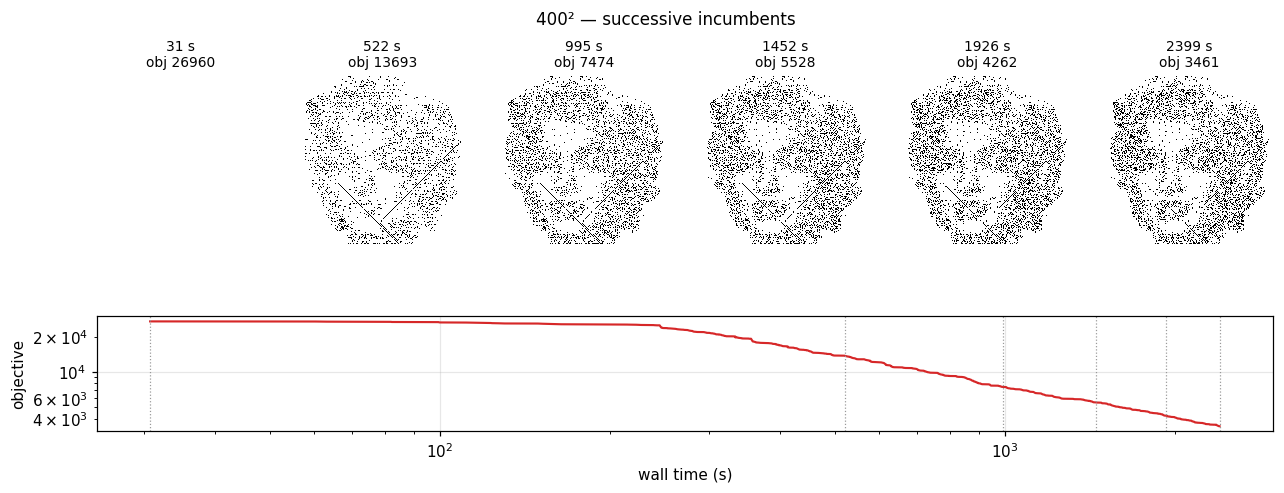

In [14]:
snaps, hist, met = movies[400]
filmstrip(snaps, hist, n_frames=6, title="400² — successive incumbents")

The filmstrip shows what the solver actually does with its time: the first
incumbent is nearly empty, the portrait's *structure* appears early, and
everything after that is density being poured into the darker windows until
the clock runs out. Nothing about the composition changes late — only how
close the shadows get to their target tone.

To put a number on it, the plot below tracks each frame's density error (MAD)
instead of the raw objective, so the three canvas sizes are comparable, and
marks where each run first gets within 10 % of its own final value.

100²: final MAD 0.0086; within 10% of it after   14.6 s of   15.2 s (96% of the run)
200²: final MAD 0.0091; within 10% of it after   88.7 s of  108.9 s (81% of the run)


400²: final MAD 0.0334; within 10% of it after 2122.4 s of 2399.4 s (88% of the run)


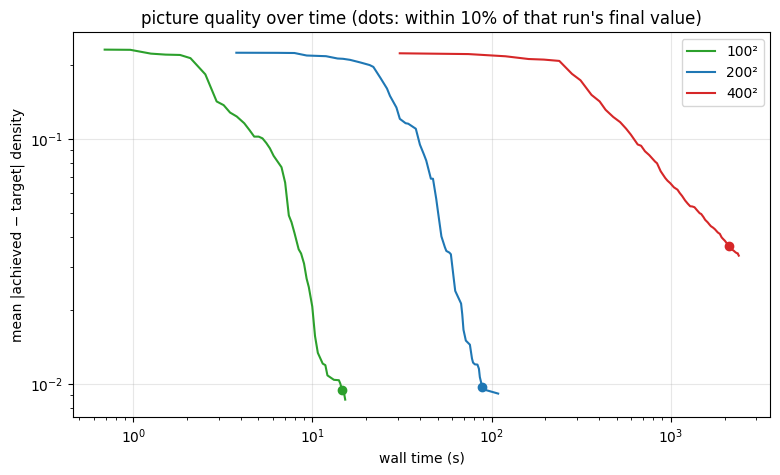

In [15]:
def frame_mads(size, snaps):
    g, f = grey_and_mask_from_image(REPO / "input/images/marilyn.png", size)
    ct = cell_targets(equalize_grey(g, f), d_max=D_MAX)
    _, kept_w = window_targets(ct, f, window_slices(ct.shape, K, K))
    n_free = np.array([f[si, sj].sum() for si, sj in kept_w])
    target = np.array([ct[si, sj][f[si, sj]].sum() for si, sj in kept_w]) / n_free
    mads = []
    for _, _, pattern in snaps:
        achieved = np.array([pattern[si, sj][f[si, sj]].sum() for si, sj in kept_w]) / n_free
        mads.append(np.abs(achieved - target).mean())
    return np.array([t for t, _, _ in snaps]), np.array(mads)

fig, ax = plt.subplots(figsize=(9, 5))
for (size, (snaps, _, _)), colour in zip(movies.items(), ("tab:green", "tab:blue", "tab:red")):
    times, mads = frame_mads(size, snaps)
    ax.plot(times, mads, "-", color=colour, label=f"{size}²")
    reached = times[mads <= mads[-1] * 1.1][0]
    ax.scatter([reached], [mads[times == reached][0]], color=colour, zorder=3)
    print(f"{size}²: final MAD {mads[-1]:.4f}; within 10% of it after "
          f"{reached:6.1f} s of {times[-1]:6.1f} s ({reached / times[-1]:.0%} of the run)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("wall time (s)")
ax.set_ylabel("mean |achieved − target| density")
ax.set_title("picture quality over time (dots: within 10% of that run's final value)")
ax.legend()
ax.grid(alpha=0.3)

**What this says about cut-off times.**

- At **100² and 200² there is nothing to decide**: the solver proves
  optimality after 15 s and 110 s, and the last few seconds are where the
  error collapses from ~0.02 to ~0.009. Cutting either run short is pure loss.
- At **400² there is no knee at all.** Density error falls roughly like 1/t
  for the whole 40 minutes — 0.104 at 10 minutes, 0.059 at 20, 0.043 at 30,
  0.033 at the cap. Every doubling of the budget buys roughly a halving of
  the error, with no point where the curve flattens out.
- So the honest advice is: **the picture is recognisable long before the run
  is worth stopping.** Structure arrives in the first few minutes; the rest of
  the budget buys shadow density, which is exactly what the tone-fidelity plot
  earlier showed to be missing. Pick the cap from how dark you need the darks,
  not from watching for convergence.
- Practical consequence: a 400² picture at the quality the 200² run reaches
  (MAD ≈ 0.009) is out of reach by brute force at ~1/t — it would take hours.
  That is the strongest argument yet for the decomposition idea in `REPORT.md`:
  solving strips separately turns one 1/t crawl into several fast, provable
  solves.

### Where the 400² solve actually loses

Total deviation is not spread evenly. Grouping windows by how dark they are
supposed to be shows that the 200² solve is flat — essentially perfect
everywhere — while the 400² incumbent is fine in the light and midtones and
misses only in the darkest windows. That is exactly where the combinatorics
bite: near the Elkies density ceiling (≈ ½) still lifes get scarce, so those
windows are the last ones the solver manages to fill.

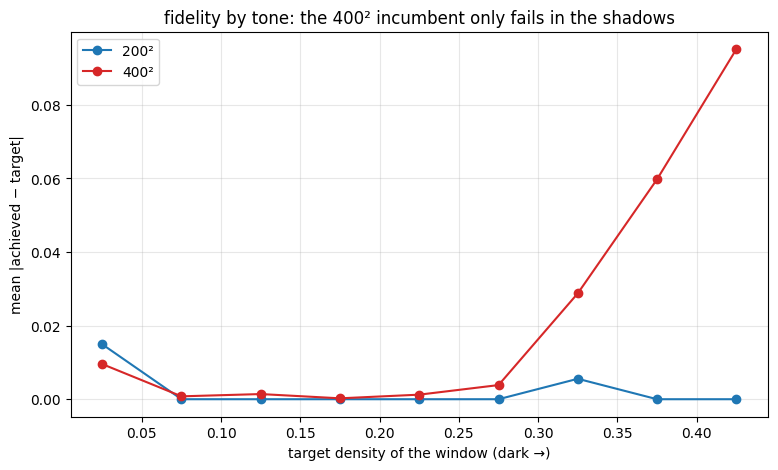

In [16]:
from beyond_tiles.targets import grey_and_mask_from_image

def window_deviation(size, pattern):
    g, f = grey_and_mask_from_image(REPO / "input/images/marilyn.png", size)
    ct = cell_targets(equalize_grey(g, f), d_max=D_MAX)
    t, kept_w = window_targets(ct, f, window_slices(ct.shape, K, K))
    n_free = np.array([f[si, sj].sum() for si, sj in kept_w])
    achieved = np.array([pattern[si, sj][f[si, sj]].sum() for si, sj in kept_w]) / n_free
    return t / n_free, np.abs(achieved - t / n_free)

fig, ax = plt.subplots(figsize=(9, 5))
edges = np.linspace(0, D_MAX, 10)
centres = (edges[:-1] + edges[1:]) / 2
for (size, pattern), colour in (((200, hires[200][0]), "tab:blue"),
                                ((400, hires[400][0]), "tab:red")):
    target, dev = window_deviation(size, pattern)
    binned = [dev[(target >= lo) & (target < hi)] for lo, hi in zip(edges[:-1], edges[1:])]
    ax.plot(centres, [b.mean() if len(b) else np.nan for b in binned],
            "o-", color=colour, label=f"{size}²")
ax.set_xlabel("target density of the window (dark →)")
ax.set_ylabel("mean |achieved − target|")
ax.set_title("fidelity by tone: the 400² incumbent only fails in the shadows")
ax.legend()
ax.grid(alpha=0.3)

### So which resolution should you use?

**Advantages of going higher**

- **Tonal resolution scales with the window grid**: 12×12 tone blocks at
  100², 25×25 at 200², 50×50 at 400². Eyes, lips and individual hair strands
  only survive from ~200² upwards.
- **Smoother gradients.** A window holds at most 64 cells at any resolution,
  so its density is quantized in steps of 1/64 — more windows across the same
  face means finer shading and less banding.
- **Texture stops competing with the image.** At 400² a still-life motif is
  small relative to an image feature, so the pattern reads as photographic
  grey rather than as ornament.
- **The "beyond tiles" claim strengthens with area**: motif diversity grows
  with the canvas, while a tile-based pipeline would need an ever larger
  vocabulary to avoid visible repetition.

**Disadvantages**

- **The optimality wall.** 16 s → 87 s → not closed in 2,404 s. Beyond ~200²
  you are looking at incumbents, not proofs.
- **Memory.** 1.2 → 2.7 → 4.6 GB peak resident. 800² will not fit in 16 GB
  with 10 workers.
- **Shadow fidelity.** Darkest-quartile MAD rises from 0.0076 (200²) to
  0.0816 (400²): dark regions come out too light, so global contrast is
  slightly compressed.
- **No natural stopping point at 400².** The movies in the next section
  show deviation falling roughly like 1/t right up to the cap — the last ten
  minutes still cut the error by a quarter — so the time limit is a budget
  decision, not a convergence one.
- **Bigger outputs**: a 400² `.cells` file is ~160 kB; still trivial for
  Golly, but printing at one cell per pixel needs a large canvas.

**A caveat against over-reading the status:** objective 2,874 spread over
1,968 windows is ~1.5 cells of deviation per 64-cell window. "Not proven
optimal" is not the same as "looks worse" — the 400² render is the most
convincing image of the whole spike.

**Recommendation.** Use 200² when you want a guarantee and a ~90-second
turnaround; use 400² with a generous time cap when the picture matters more
than the proof. For anything larger, the way forward is decomposition —
solving overlapping horizontal strips with frozen boundary rows — which is
listed as future work in `REPORT.md`.

In [17]:
RUN_HIGHRES = False  # flip to True to reproduce the 200² solve (~90 s on an M4)

if RUN_HIGHRES:
    grey_hi, free_hi = grey_and_mask_from_image(REPO / "input/images/marilyn.png", 200)
    eq_hi = equalize_grey(grey_hi, free_hi)
    cfg_hi = SpikeConfig(k=8, stride=8, d_max=0.45, time_limit_s=300.0, workers=10, seed=0)
    result_hi = solve_image(eq_hi, free_hi, cfg_hi)
    print(result_hi.status, result_hi.objective, f"{result_hi.wall_time_s:.1f}s")

# Equivalent from the command line (writes renders, .cells and metrics under results/):
#   python experiments/beyond_tiles/run_experiment.py e2 --size 200 --stride 8 \
#       --tone eq --time 300
# The 400² run is the same command with --size 400 --time 2400.

## 9. Beyond this demo

- The experiment driver reproduces everything in the spike:
  `python experiments/beyond_tiles/run_experiment.py e2 --size 200 --stride 8 --tone eq`
- Measured scaling with disjoint windows (Apple M4, 10 workers): 100² in
  16 s, 200² in 87 s, both to proven optimality — see
  `experiments/beyond_tiles/REPORT.md` for the full E1–E5 analysis, the
  texture census proving the result is genuinely non-tiled (92% of 6×6
  blocks unique), and the comparison with tile mosaics and with Verrill's
  annealing approach.
- Seeds are the "new variation" knob: same image, same quality, different
  pattern.